In [3]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import tqdm
import pyro
import sys

sc.settings.figdir=os.path.expanduser('~/WbFigures/SpeciesDivergenceNoScaling')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

sys.path.append('/home/matthew.schmitz/Matthew/code/scANTIPODE/')
import antipode


GPU is not available


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [4]:
adata=sc.read_h5ad('/home/matthew.schmitz/Matthew/1.9.1.5_Retina.h5ad',backed='r')

In [5]:
discov_key='species'
batch_key='batch'

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


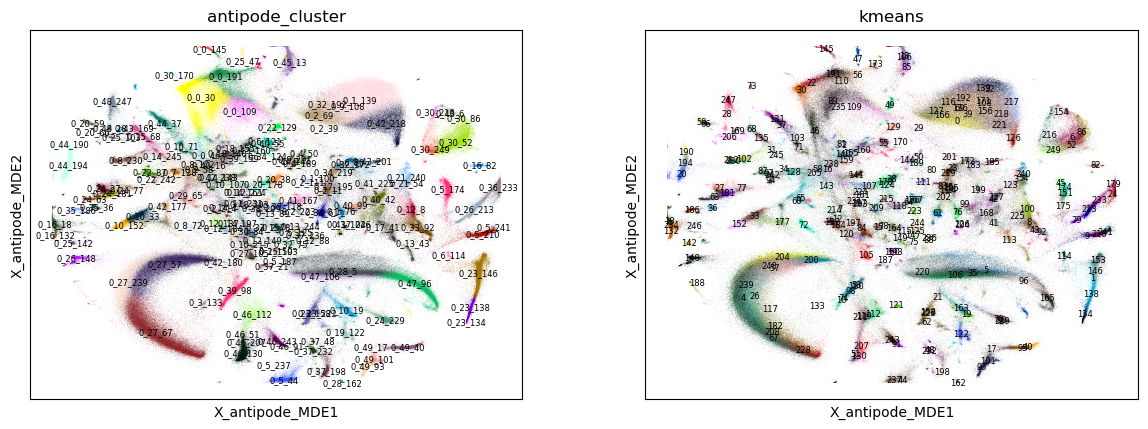

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value t

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


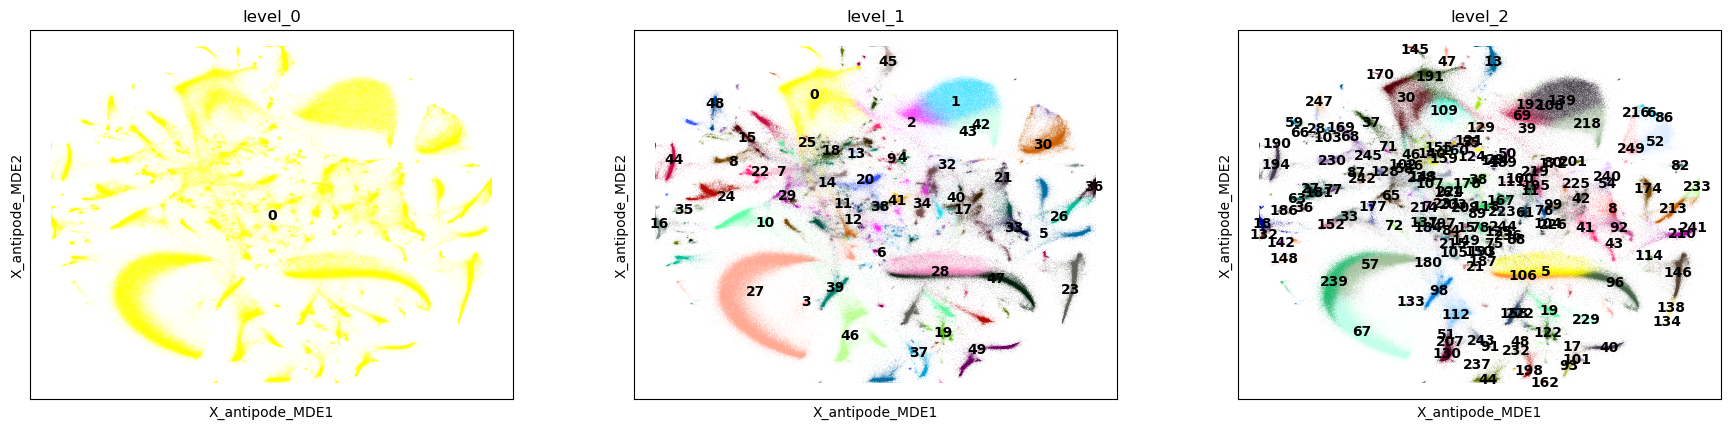

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/matthew.schmitz/Matthew/utils/miniforge3/envs/pyro/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


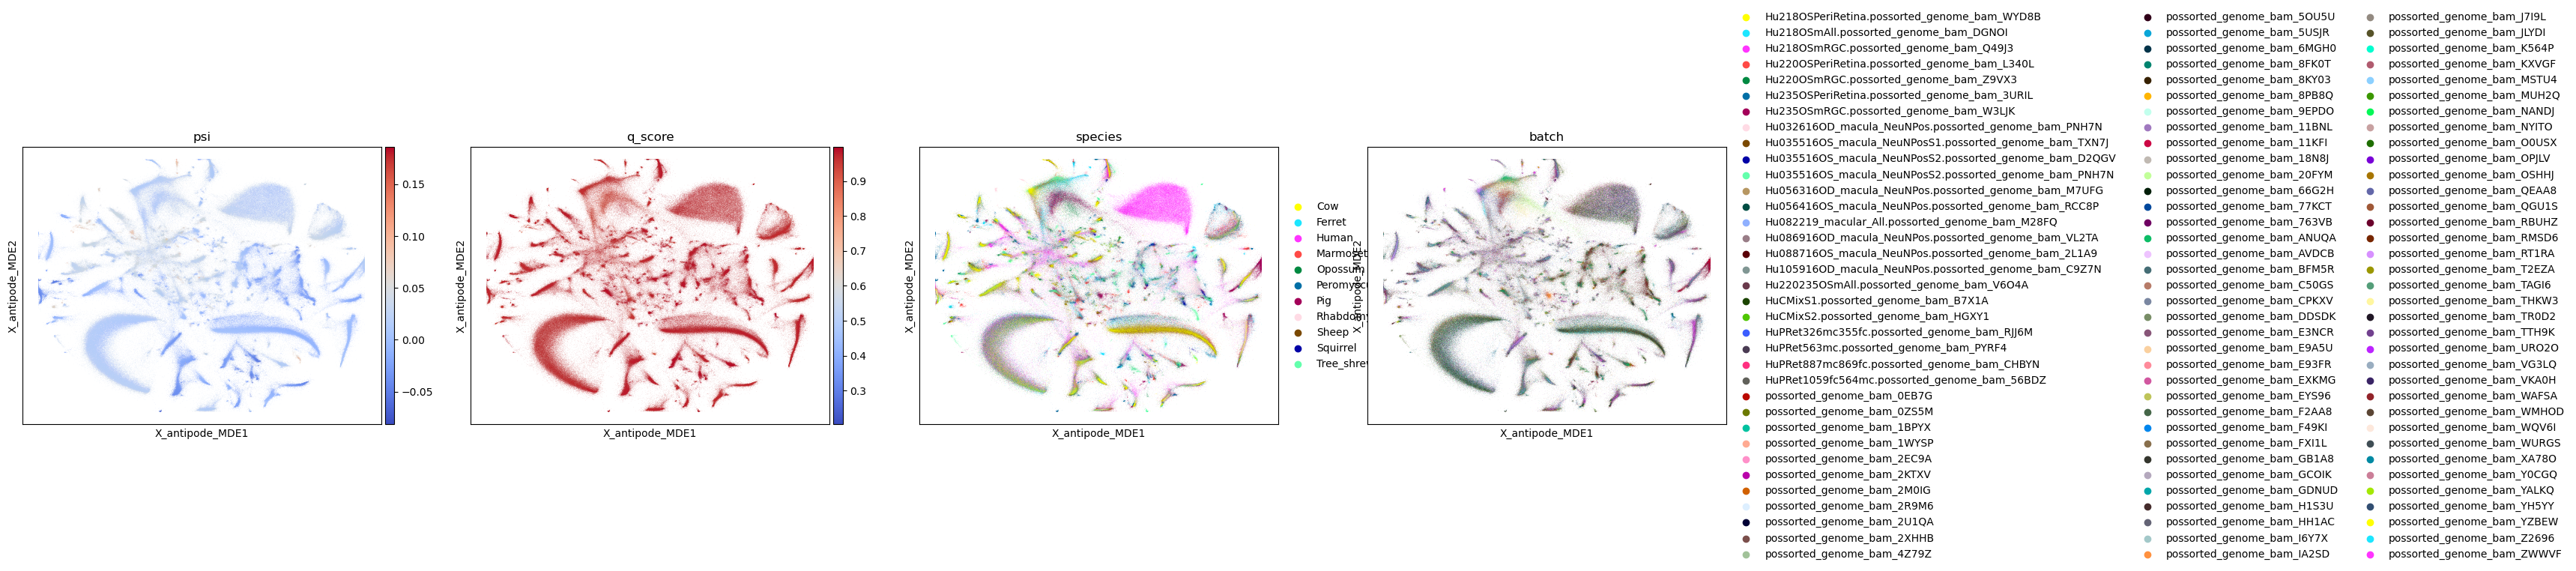

In [7]:
MDE_KEY = "X_antipode_MDE"

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster","kmeans"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["psi",'q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)



In [ ]:
import sys
d={}
for k in adata.uns['param_store'].keys():
    d[k]=sys.getsizeof(adata.uns['param_store'][k])

df=pd.DataFrame(d.values())
df.index=d.keys()
df_melted = df.T.melt(value_vars=df.index)
# Plotting
plt.figure(figsize=(10, 6))  # Adjust the figure size to ensure labels don't overlap
seaborn.barplot(x='variable', y='value', data=df_melted)
plt.xticks(rotation=90)  # Rotate the labels if necessary
plt.show()


In [50]:
pstore=adata.uns['param_store']

array([[-1.31898685e-02, -4.74537569e-03, -1.45439459e-03, ...,
         4.85033785e-02, -5.86546110e-02, -2.78657632e-02],
       [-1.31898685e-02, -4.74537569e-03, -1.45439459e-03, ...,
         4.85033785e-02, -5.86546110e-02, -2.78657632e-02],
       [ 3.55705842e-03, -1.77965480e-03,  1.54671003e-03, ...,
         2.67905887e-05, -4.84953651e-03, -2.26241851e-03],
       ...,
       [ 3.00469578e-03, -4.12232630e-03, -1.64418207e-02, ...,
         1.64039417e-02,  1.30291565e-03,  1.01051351e-03],
       [-2.42339212e-03, -7.87124646e-03, -7.52529173e-03, ...,
        -2.29007680e-03, -8.45282358e-05,  1.81335468e-03],
       [ 4.34272320e-03, -6.58947714e-03,  1.47484653e-03, ...,
         1.42298439e-03, -7.60939702e-03,  1.79540278e-03]])

In [71]:
loc_dynams.shape

(2290611, 150)

In [ ]:
loc_dynams=adata.obsm['taxon_probs']@pstore['locs_dynam']*np.expand_dims(adata.obs['psi'].to_numpy(),axis=-1)
cluster_means=(((adata.obsm['taxon_probs']@pstore['locs']+loc_dynams)@pstore['z_decoder_weight'])+pstore['cluster_intercept'])
cluster_params=(np.sign(cluster_means)*0) + cluster_means
coefs=[]
for i in tqdm.tqdm(range(cluster_params.shape[0])):
    others=list(set(list(range(cluster_params.shape[0])))-set([i]))
    coefs.append((cluster_params[i:(i+1),:]-cluster_params[others,:].mean(0))/(cluster_params.std(0)))
coefs=np.concatenate(coefs,axis=0)



In [ ]:
sc.pl.dotplot(adata,groupby='antipode_cluster',var_names=pd.DataFrame(coefs.T,index=adata.var.index).idxmax(0),dendrogram=False,standard_scale='var',use_raw=False,cmap='coolwarm')

In [ ]:
def gex_output(x,m,b):
    return((x@m+b).detach())

In [4]:
adata.write_h5ad('/home/matthew.schmitz/Matthew/1.9.1.6_Devanalysisinprogress.h5ad')
